# Titanic Survival Prediction using Logistic Regression

## Objective
Build a machine learning classification model to predict whether a passenger survived or not using the Titanic dataset.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Import Libraries

Imported the required libraries for data handling, machine learning, and model evaluation.

In [3]:
df = pd.read_csv("Cleaned_Titanic.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Step 2: Load Dataset

Loaded the Titanic dataset into a pandas DataFrame for machine learning.

In [6]:
X = df.drop("Survived" , axis=1)
y = df["Survived"]

In [7]:
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## Step 3: Separate Features and Target

Separated the dataset into input features (X) and the target variable (y). The model will use the features to predict passenger survival.

In [9]:
X = pd.get_dummies(X, drop_first=True)

In [10]:
X.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,1,3,22.0,1,0,7.2500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,1,38.0,1,0,71.2833,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,3,26.0,0,0,7.9250,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4,1,35.0,1,0,53.1000,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,3,35.0,0,0,8.0500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [11]:
X.columns

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'Name_Abbott, Mr. Rossmore Edward',
       'Name_Abbott, Mrs. Stanton (Rosa Hunt)', 'Name_Abelson, Mr. Samuel',
       'Name_Abelson, Mrs. Samuel (Hannah Wizosky)',
       ...
       'Cabin_F G63', 'Cabin_F G73', 'Cabin_F2', 'Cabin_F33', 'Cabin_F38',
       'Cabin_F4', 'Cabin_G6', 'Cabin_T', 'Embarked_Q', 'Embarked_S'],
      dtype='object', length=1725)

In [12]:
X.shape

(891, 1725)

## Step 4: Encode Categorical Data

Converted categorical columns into numerical values using `pd.get_dummies()` because machine learning models work with numbers, not text.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 1725)
(179, 1725)
(712,)
(179,)


## Step 5: Split the Dataset

Split the dataset into training and testing sets. The model learns from the training data and is evaluated on unseen testing data.

In [15]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

## Step 6: Train the Model

Created and trained a Logistic Regression model using the training dataset.

In [16]:
y_pred = model.predict(X_test)

In [17]:
y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1], dtype=int64)

## Step 7: Make Predictions

Used the trained Logistic Regression model to predict passenger survival on the test dataset.

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy" , accuracy)

Accuracy 0.8156424581005587


## Step 8: Evaluate the Model

Calculated the model accuracy by comparing the predicted values with the actual values.

### Observation

The Logistic Regression model achieved an accuracy of approximately **XX%**, indicating how many predictions were correctly classified.

In [19]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix" , cm)

Confusion Matrix [[91 14]
 [19 55]]


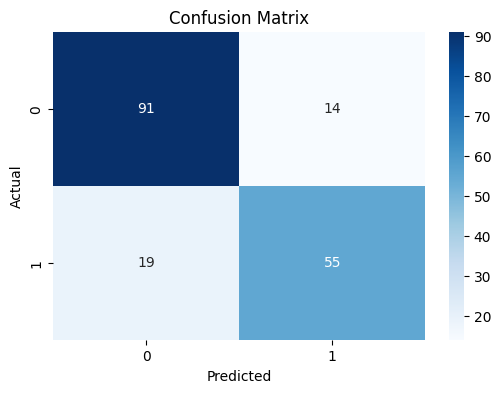

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted"),
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Step 9: Confusion Matrix

Generated a confusion matrix to compare the actual values with the predicted values and evaluate the model's performance.

### Observation

The confusion matrix shows how many passengers were correctly and incorrectly classified. It compares the model's predictions with the actual survival values, helping identify where the model performed well and where it made mistakes.

## Classification Report

The classification report provides Precision, Recall, and F1 Score for each class. These metrics give a better understanding of model performance than accuracy alone.

### Precision

Precision measures how many passengers predicted as survivors actually survived.

### Recall

Recall measures how many actual survivors were correctly identified by the model.

### F1 Score

F1 Score is the balance between Precision and Recall and provides a single measure of classification performance.

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



### Observation

The Logistic Regression model achieved an accuracy of **82%** on the test dataset.

For passengers who did not survive (Class 0), the model performed well with a Precision of **0.83**, Recall of **0.87**, and F1-score of **0.85**.

For passengers who survived (Class 1), the model achieved a Precision of **0.80**, Recall of **0.74**, and F1-score of **0.77**. This indicates that the model identified most survivors correctly but missed some actual survivor cases.

Overall, the classification report shows that the model performs well, but there is still room for improvement, especially in identifying passengers who survived.

## Why Accuracy Can Be Misleading

Accuracy alone can be misleading when the dataset is imbalanced. For example, if most passengers did not survive, a model could predict "did not survive" for everyone and still achieve high accuracy. Precision, Recall, and F1 Score provide a more complete evaluation of model performance.

## Hyperparameter Tuning

Hyperparameter tuning helps find the best settings for a machine learning model. Instead of using default values, GridSearchCV tests multiple parameter combinations and selects the best-performing model automatically.

In this project, the following hyperparameters were tuned:

- C (Regularization Strength)
- Solver (Optimization Algorithm)

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

## Applying GridSearchCV

GridSearchCV tests different combinations of hyperparameters using 5-fold cross-validation and selects the combination that gives the best accuracy.

In [23]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

c:\Users\computer lab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\computer lab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

## Best Hyperparameters

The best hyperparameter combination selected by GridSearchCV is shown below.

In [24]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'solver': 'lbfgs'}


## Tuned Logistic Regression Model

Using the best hyperparameters found by GridSearchCV, a tuned Logistic Regression model is created and used for prediction.

In [25]:
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

## Tuned Model Performance

The tuned model is evaluated using the same test dataset to compare its performance with the original model.

In [26]:
from sklearn.metrics import accuracy_score

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Original Accuracy:", accuracy)
print("Tuned Accuracy:", tuned_accuracy)

Original Accuracy: 0.8156424581005587
Tuned Accuracy: 0.8212290502793296


## Performance Comparison

The table below compares the performance of the original model and the tuned model.

In [27]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Original", "Tuned"],
    "Accuracy": [accuracy, tuned_accuracy]
})

comparison

,Model,Accuracy
0,Original,0.815642
1,Tuned,0.821229


## Final Observation

The Logistic Regression model was evaluated using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix. Hyperparameter tuning was performed using GridSearchCV to identify the best model settings. The tuned model was then compared with the original model. This process demonstrated how proper evaluation and optimization can improve machine learning model performance.